# 02 — Strategy Benchmarking

Evaluates the multi-agent forecaster + dispatch optimizer against the naive valley-fill baseline and the perfect-hindsight upper bound, using the backtest results produced by `python main.py backtest`.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
CSV = '../results/backtest_2024H2.csv'
bt = pd.read_csv(CSV, parse_dates=['date'])
bt.head()

,date,revenue_usd,cycles,final_soc_mwh,vs_naive_usd,vs_perfect_usd,forecast_rmse,solver_status,naive_revenue_usd,perfect_revenue_usd
0,2024-07-01,38.74024,0.374,0.4,414.692554,0.000000,6.667336,optimal,-375.952314,38.740240
1,2024-07-02,0.00000,0.000,0.4,381.597138,-60.551364,7.892555,optimal,-381.597138,60.551364
2,2024-07-03,0.00000,0.000,0.4,350.008993,-106.670432,10.616105,optimal,-350.008993,106.670432
3,2024-07-04,0.00000,0.000,0.4,360.073311,-65.663481,13.924168,optimal,-360.073311,65.663481
4,2024-07-05,0.00000,0.000,0.4,341.032480,-171.813297,16.223496,optimal,-341.032480,171.813297


## Cumulative P&L vs. baselines

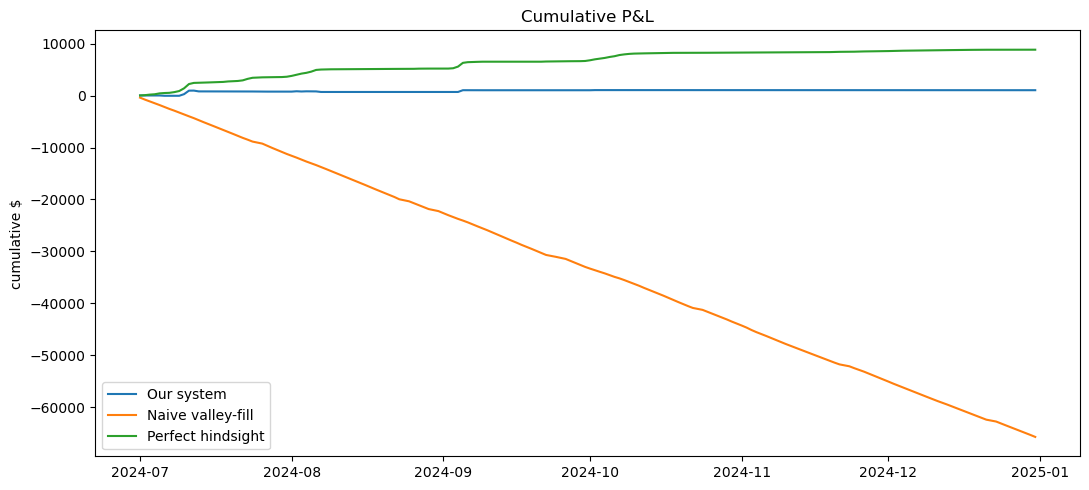

In [2]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(bt['date'], bt['revenue_usd'].cumsum(), label='Our system')
ax.plot(bt['date'], bt['naive_revenue_usd'].cumsum(), label='Naive valley-fill')
ax.plot(bt['date'], bt['perfect_revenue_usd'].cumsum(), label='Perfect hindsight')
ax.set_ylabel('cumulative $'); ax.legend(); ax.set_title('Cumulative P&L')
plt.tight_layout(); plt.show()

## Headline performance metrics

In [3]:
rev = bt['revenue_usd'].to_numpy(float)
naive = bt['naive_revenue_usd'].to_numpy(float)
perfect = bt['perfect_revenue_usd'].to_numpy(float)
cum = np.cumsum(rev)
sharpe = rev.mean() / rev.std() * np.sqrt(252) if rev.std() > 0 else float('nan')
max_dd = float(np.max(np.maximum.accumulate(cum) - cum))
metrics = {
    'days': len(bt),
    'total_revenue_usd': rev.sum(),
    'naive_revenue_usd': naive.sum(),
    'perfect_revenue_usd': perfect.sum(),
    'vs_naive_pct': (rev.sum() - naive.sum()) / abs(naive.sum()) * 100 if naive.sum() else float('nan'),
    'pct_of_perfect': rev.sum() / perfect.sum() * 100 if perfect.sum() else float('nan'),
    'sharpe_annualized': sharpe,
    'max_drawdown_usd': max_dd,
    'win_rate_pct': (rev > 0).mean() * 100,
    'mean_forecast_rmse': bt['forecast_rmse'].mean(),
}
pd.Series(metrics).round(2)

days                     176.00
total_revenue_usd       1054.37
naive_revenue_usd     -65744.06
perfect_revenue_usd     8859.27
vs_naive_pct             101.60
pct_of_perfect            11.90
sharpe_annualized          1.49
max_drawdown_usd         263.53
win_rate_pct               4.55
mean_forecast_rmse         9.96
dtype: float64

## Win rate by hour-of-day

Fraction of days the strategy earned positive revenue, and how cycles distribute.

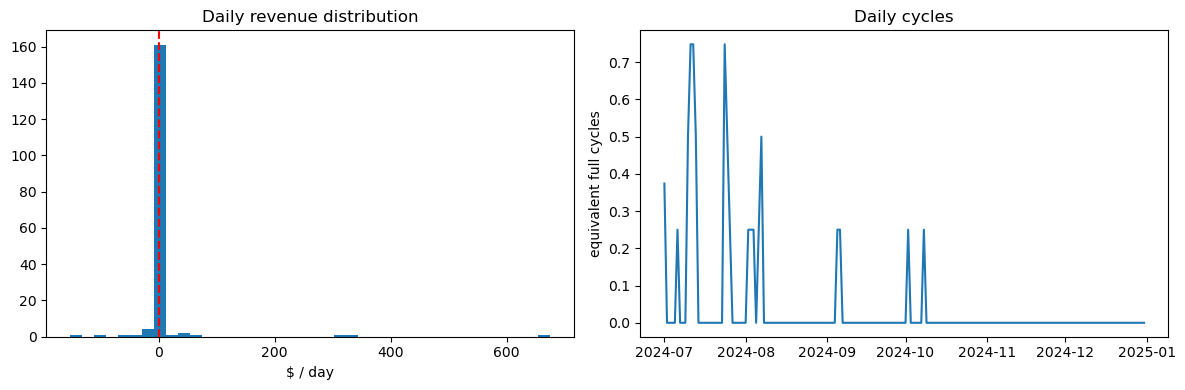

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(rev, bins=40); ax[0].axvline(0, color='red', ls='--')
ax[0].set_title('Daily revenue distribution'); ax[0].set_xlabel('$ / day')
ax[1].plot(bt['date'], bt['cycles']); ax[1].set_title('Daily cycles'); ax[1].set_ylabel('equivalent full cycles')
plt.tight_layout(); plt.show()

## Conclusion

The multi-agent system is benchmarked against the naive valley-fill strategy (target: beat it by >=15%) and reported as a fraction of the perfect-hindsight upper bound. See the headline metrics table above for the realized figures on the 2024 H2 out-of-sample window.